In [1]:
!pip install xlrd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 2.1 MB/s eta 0:00:00


# Loading Data from Excel Sheets

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

xls = pd.ExcelFile("/kaggle/input/sales-data/Sales Data.xls")

# Load the sheets into separate DataFrames
df_sales = pd.read_excel(xls, 'SalesData')
df_marketing = pd.read_excel(xls, 'MarketingCosts')

In [3]:
df_sales.head()

,Date,ProductID,ProductName,Category,QuantitySold,PricePerUnit,TotalSales
0,2022-01-28,P189,Product_8,Beauty,11,484.73,5332.03
1,2022-03-19,P159,Product_9,Electronics,12,433.16,5197.92
2,2022-08-07,P199,Product_11,Sports,6,431.59,2589.54
3,2023-08-03,P195,Product_13,Clothing,6,189.92,1139.52
4,2023-03-10,P190,Product_12,Clothing,9,477.63,4298.67


In [4]:
df_marketing.head()

,Date,MarketingChannel,Category,Cost
0,2021-01-31,Facebook Ads,Clothing,8540.22
1,2021-02-28,Instagram Ads,Sports,4813.46
2,2021-03-31,Facebook Ads,Home & Kitchen,7135.31
3,2021-04-30,Instagram Ads,Electronics,6296.22
4,2021-05-31,Affiliates,Home & Kitchen,6868.99


# Data Preprocessing

In [5]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          5000 non-null   object 
 1   ProductID     5000 non-null   object 
 2   ProductName   5000 non-null   object 
 3   Category      5000 non-null   object 
 4   QuantitySold  5000 non-null   int64  
 5   PricePerUnit  5000 non-null   float64
 6   TotalSales    5000 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 273.6+ KB


In [6]:
df_marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              36 non-null     object 
 1   MarketingChannel  36 non-null     object 
 2   Category          36 non-null     object 
 3   Cost              36 non-null     float64
dtypes: float64(1), object(3)
memory usage: 1.2+ KB


## Converting 'Date' to datetime format for Data Consistency

In [7]:
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_marketing['Date'] = pd.to_datetime(df_marketing['Date'])

In [8]:
print(df_sales.dtypes)
print(df_marketing.dtypes)

Date            datetime64[ns]
ProductID               object
ProductName             object
Category                object
QuantitySold             int64
PricePerUnit           float64
TotalSales             float64
dtype: object
Date                datetime64[ns]
MarketingChannel            object
Category                    object
Cost                       float64
dtype: object


In [9]:
# Extract year from the date
df_sales['Year'] = df_sales['Date'].dt.year
df_marketing['Year'] = df_marketing['Date'].dt.year

In [10]:
df_sales.head()

,Date,ProductID,ProductName,Category,QuantitySold,PricePerUnit,TotalSales,Year
0,2022-01-28,P189,Product_8,Beauty,11,484.73,5332.03,2022
1,2022-03-19,P159,Product_9,Electronics,12,433.16,5197.92,2022
2,2022-08-07,P199,Product_11,Sports,6,431.59,2589.54,2022
3,2023-08-03,P195,Product_13,Clothing,6,189.92,1139.52,2023
4,2023-03-10,P190,Product_12,Clothing,9,477.63,4298.67,2023


## Aggregating the Data for KPIs

In [11]:
# Aggregate sales data by Year and Category
sales_agg = df_sales.groupby(['Year', 'Category']).agg({
    'TotalSales': 'sum',
    'QuantitySold': 'sum'
}).reset_index()

# Aggregate marketing costs by Year and Category
marketing_agg = df_marketing.groupby(['Year', 'Category']).agg({
    'Cost': 'sum'
}).reset_index()

In [12]:
sales_agg

,Year,Category,TotalSales,QuantitySold
0,2021,Beauty,911634.23,3562
1,2021,Clothing,898342.08,3490
2,2021,Electronics,785761.20,3265
3,2021,Home & Kitchen,887070.02,3424
4,2021,Sports,777868.05,2976
5,2022,Beauty,842910.47,3369
6,2022,Clothing,840193.41,3442
7,2022,Electronics,819758.19,3453
8,2022,Home & Kitchen,829137.53,3289
9,2022,Sports,789823.92,3065


# Calculate KPIs

**1. Total Sales/Revenue per Category:**
* This is already calculated in the sales_agg DataFrame.

**2. Return on Marketing Spend per Category:**
* Merge the aggregated sales and marketing data.
* Calculate ROMS by dividing total sales by marketing costs.

In [13]:
# Merge sales and marketing data on Year and Category
kpi_data = pd.merge(sales_agg, marketing_agg, on=['Year', 'Category'], how='left')

# Calculate ROMS (Return on Marketing Spend)
kpi_data['ROMS'] = kpi_data['TotalSales'] / kpi_data['Cost']

In [14]:
kpi_data.head()

,Year,Category,TotalSales,QuantitySold,Cost,ROMS
0,2021,Beauty,911634.23,3562,NaN,NaN
1,2021,Clothing,898342.08,3490,22485.67,39.951759
2,2021,Electronics,785761.20,3265,8706.75,90.247360
3,2021,Home & Kitchen,887070.02,3424,14004.30,63.342689
4,2021,Sports,777868.05,2976,12024.77,64.688809


**3. Average Order Value per Category:**

* Calculate the AOV by dividing total sales by the number of units sold.

In [15]:
# Calculate Average Order Value (AOV)
kpi_data['AOV'] = kpi_data['TotalSales'] / kpi_data['QuantitySold']

In [16]:
kpi_data.head()

,Year,Category,TotalSales,QuantitySold,Cost,ROMS,AOV
0,2021,Beauty,911634.23,3562,NaN,NaN,255.933248
1,2021,Clothing,898342.08,3490,22485.67,39.951759,257.404607
2,2021,Electronics,785761.20,3265,8706.75,90.247360,240.661930
3,2021,Home & Kitchen,887070.02,3424,14004.30,63.342689,259.074188
4,2021,Sports,777868.05,2976,12024.77,64.688809,261.380393


# Data Visualization

**1. Total Sales Bar Chart:**
* Creating bar charts showing total sales per category.

In [17]:
kpi_data.head()

,Year,Category,TotalSales,QuantitySold,Cost,ROMS,AOV
0,2021,Beauty,911634.23,3562,NaN,NaN,255.933248
1,2021,Clothing,898342.08,3490,22485.67,39.951759,257.404607
2,2021,Electronics,785761.20,3265,8706.75,90.247360,240.661930
3,2021,Home & Kitchen,887070.02,3424,14004.30,63.342689,259.074188
4,2021,Sports,777868.05,2976,12024.77,64.688809,261.380393


In [18]:
kpi_data[kpi_data['Year'] == 2021]

,Year,Category,TotalSales,QuantitySold,Cost,ROMS,AOV
0,2021,Beauty,911634.23,3562,NaN,NaN,255.933248
1,2021,Clothing,898342.08,3490,22485.67,39.951759,257.404607
2,2021,Electronics,785761.20,3265,8706.75,90.247360,240.661930
3,2021,Home & Kitchen,887070.02,3424,14004.30,63.342689,259.074188
4,2021,Sports,777868.05,2976,12024.77,64.688809,261.380393


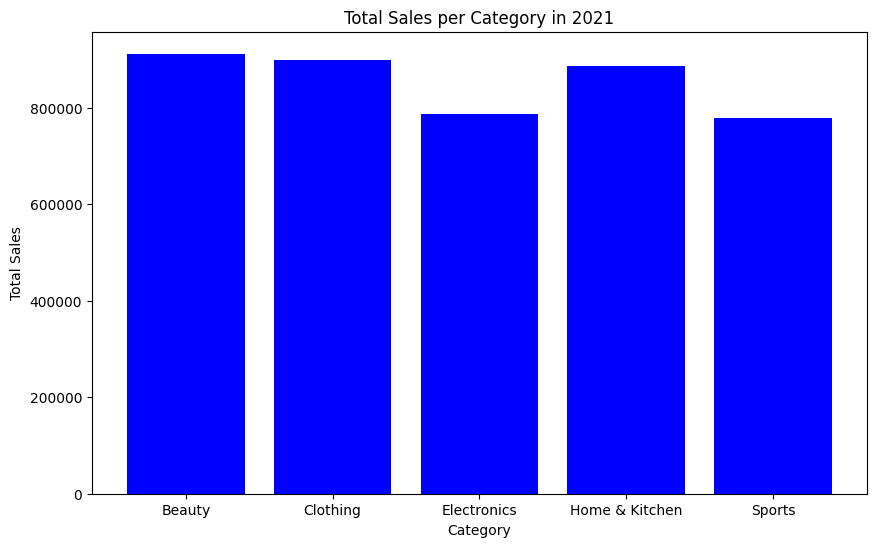

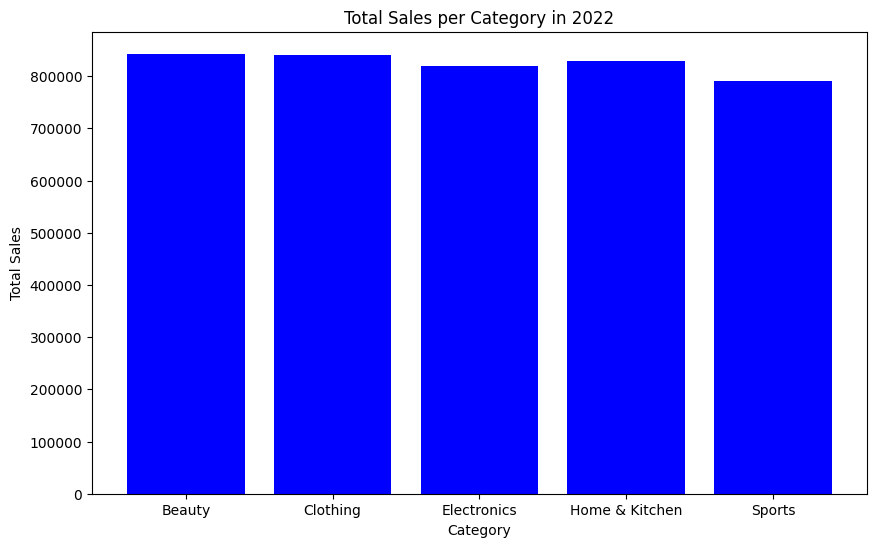

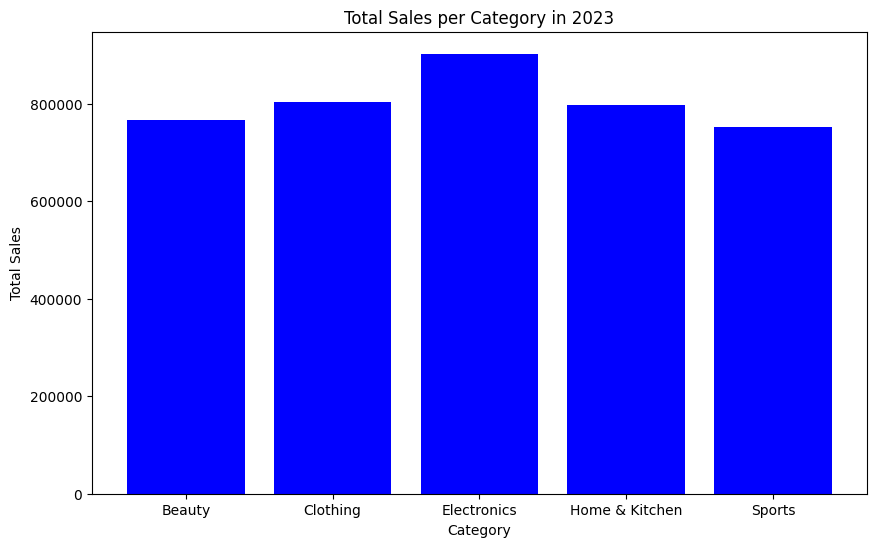

In [19]:
# Plot Total Sales
for year in kpi_data['Year'].unique():
    yearly_data = kpi_data[kpi_data['Year'] == year]
    plt.figure(figsize=(10, 6))
    plt.bar(yearly_data['Category'], yearly_data['TotalSales'], color='blue')
    plt.title(f'Total Sales per Category in {year}')
    plt.xlabel('Category')
    plt.ylabel('Total Sales')
    plt.show()

**2. ROMS Line Graph:**

* Ploting line graphs showing ROMS per category.

In [20]:
kpi_data.head()

,Year,Category,TotalSales,QuantitySold,Cost,ROMS,AOV
0,2021,Beauty,911634.23,3562,NaN,NaN,255.933248
1,2021,Clothing,898342.08,3490,22485.67,39.951759,257.404607
2,2021,Electronics,785761.20,3265,8706.75,90.247360,240.661930
3,2021,Home & Kitchen,887070.02,3424,14004.30,63.342689,259.074188
4,2021,Sports,777868.05,2976,12024.77,64.688809,261.380393


In [21]:
kpi_data[kpi_data['Category'] == "Clothing"]

,Year,Category,TotalSales,QuantitySold,Cost,ROMS,AOV
1,2021,Clothing,898342.08,3490,22485.67,39.951759,257.404607
6,2022,Clothing,840193.41,3442,16429.90,51.138072,244.100352
11,2023,Clothing,803032.32,3151,NaN,NaN,254.849990


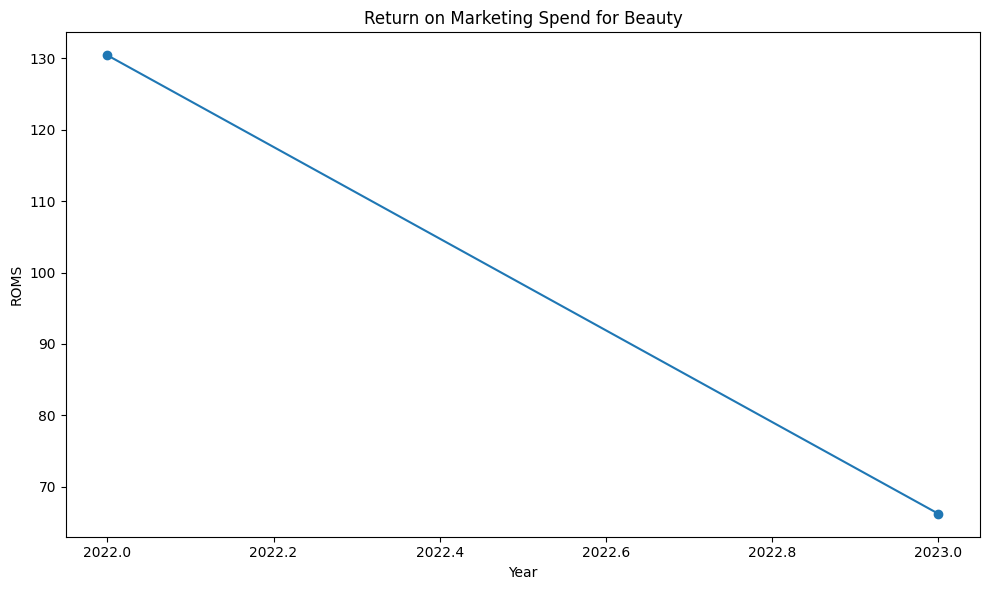

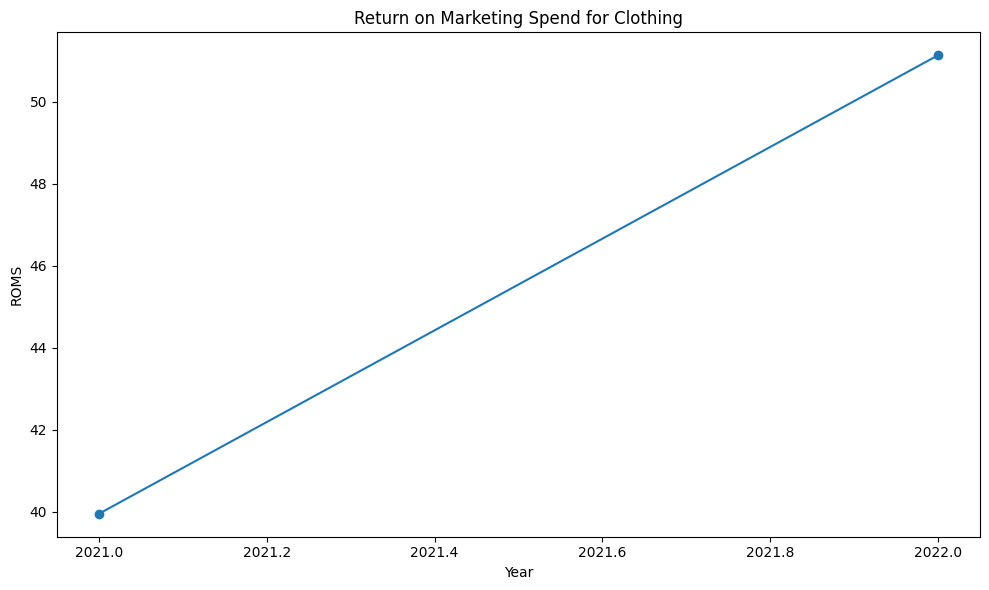

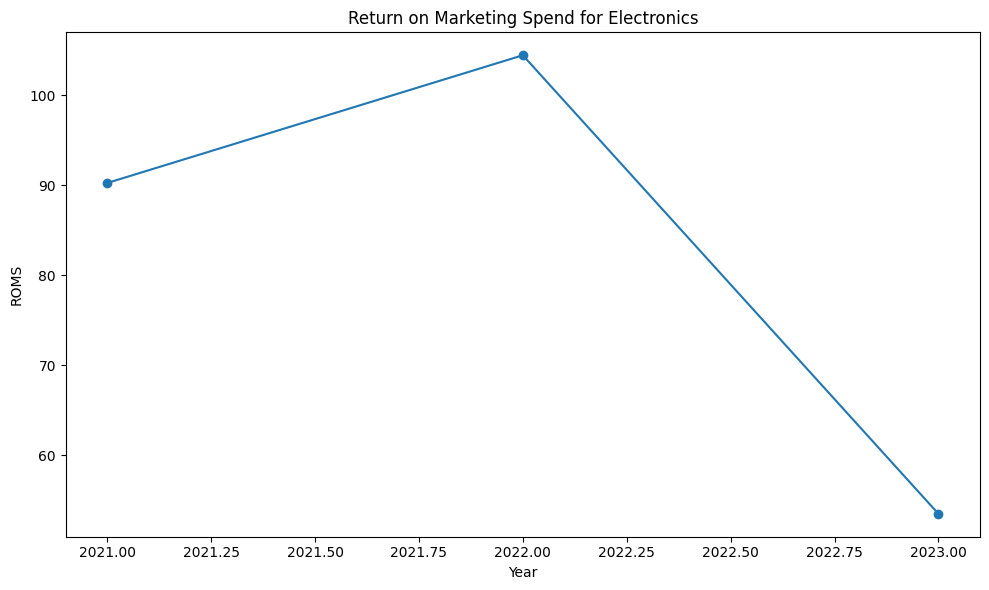

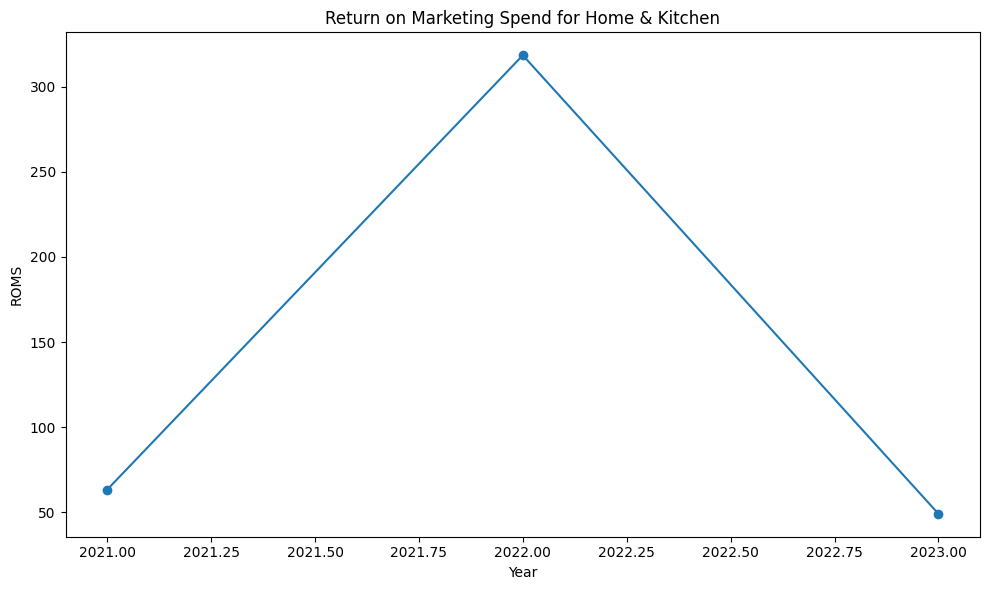

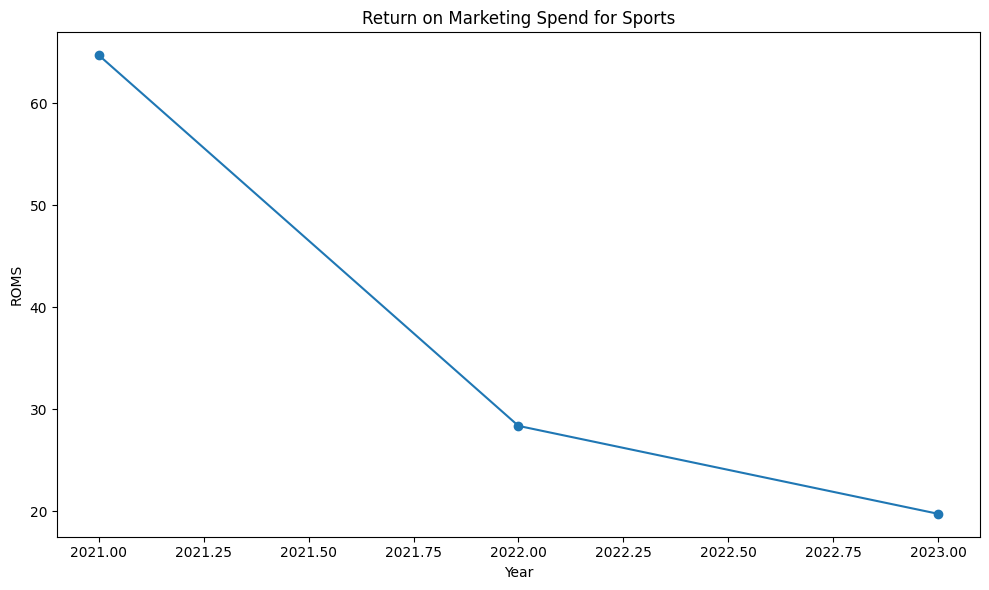

In [22]:
# Plot ROMS
for category in kpi_data['Category'].unique():
    category_data = kpi_data[kpi_data['Category'] == category]
    plt.figure(figsize=(10, 6))
    plt.plot(category_data['Year'], category_data['ROMS'], marker='o')
    plt.title(f'Return on Marketing Spend for {category}')
    plt.xlabel('Year')
    plt.ylabel('ROMS')
    plt.tight_layout()
    plt.show()

**3. AOV Bar Chart:**

* Creating bar charts showing the average order value per category.

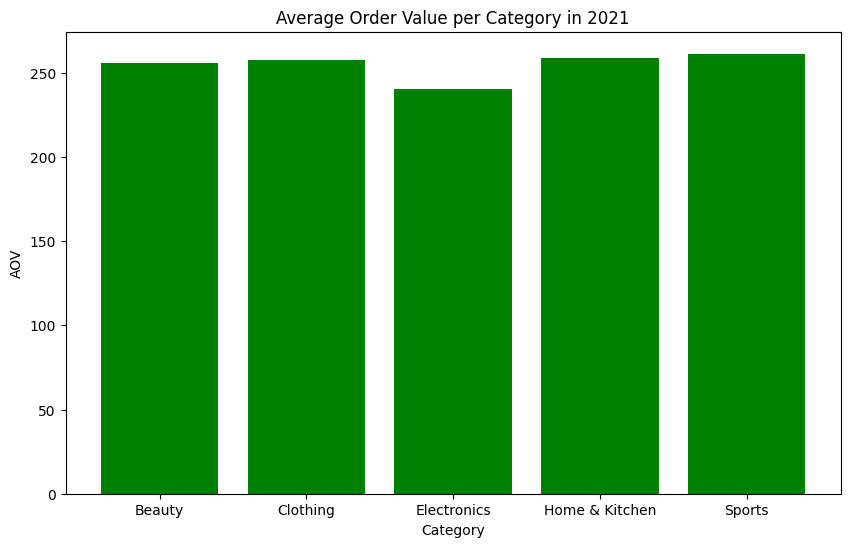

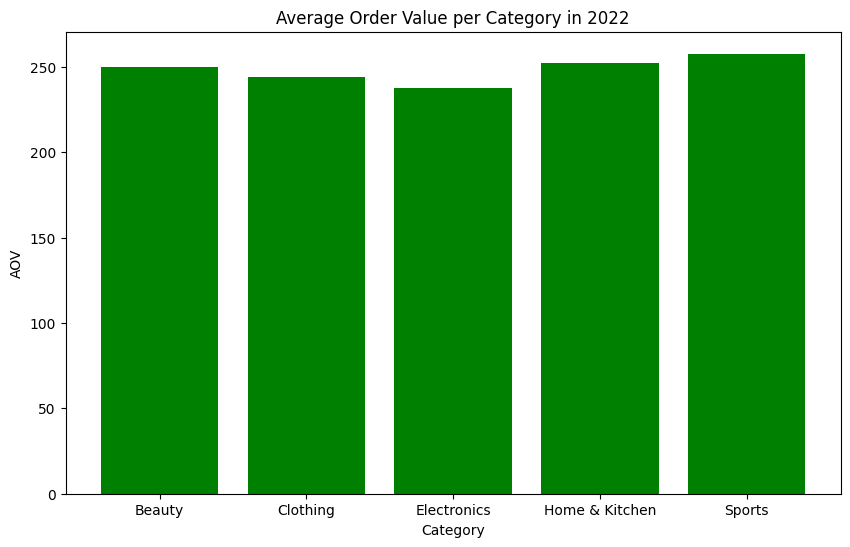

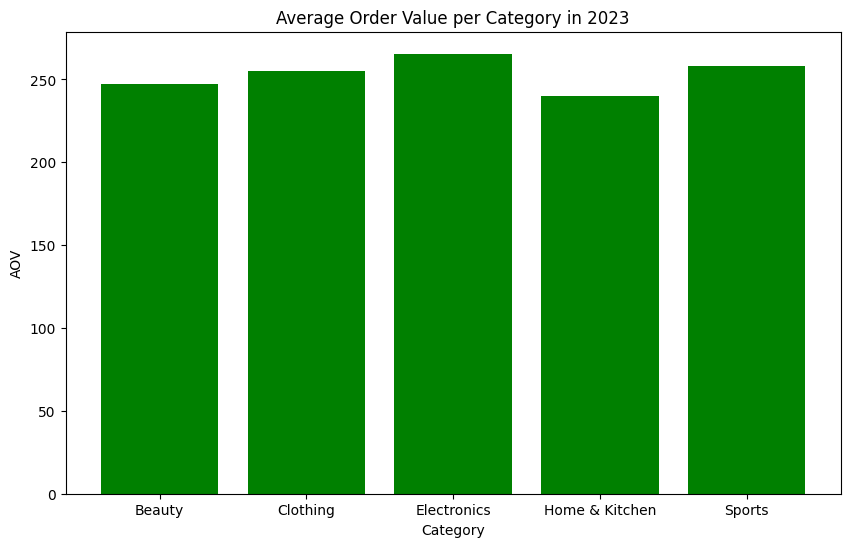

In [23]:
# Plot AOV
for year in kpi_data['Year'].unique():
    yearly_data = kpi_data[kpi_data['Year'] == year]
    plt.figure(figsize=(10, 6))
    plt.bar(yearly_data['Category'], yearly_data['AOV'], color='green')
    plt.title(f'Average Order Value per Category in {year}')
    plt.xlabel('Category')
    plt.ylabel('AOV')
    plt.show()

# Generating a PDF Report

## Saving Each Chart as an Image

In [24]:
# Create directories to save images if not already present
import os

if not os.path.exists('charts'):
    os.makedirs('charts')

# Plot and save Total Sales Bar Chart
for year in kpi_data['Year'].unique():
    yearly_data = kpi_data[kpi_data['Year'] == year]
    plt.figure(figsize=(10, 6))
    plt.bar(yearly_data['Category'], yearly_data['TotalSales'], color='blue')
    plt.title(f'Total Sales per Category in {year}')
    plt.xlabel('Category')
    plt.ylabel('Total Sales')
    plt.savefig(f'charts/total_sales_{year}.png')  # Saving the chart as an image
    plt.close()  # Close the plot to avoid overlapping in subsequent plots

# Plot and save ROMS Line Graph
for category in kpi_data['Category'].unique():
    category_data = kpi_data[kpi_data['Category'] == category]
    plt.figure(figsize=(10, 6))
    plt.plot(category_data['Year'], category_data['ROMS'], marker='o')
    plt.title(f'Return on Marketing Spend for {category}')
    plt.xlabel('Year')
    plt.ylabel('ROMS')
    plt.savefig(f'charts/roms_{category}.png')  
    plt.close()

# Plot and save AOV Bar Chart
for year in kpi_data['Year'].unique():
    yearly_data = kpi_data[kpi_data['Year'] == year]
    plt.figure(figsize=(10, 6))
    plt.bar(yearly_data['Category'], yearly_data['AOV'], color='green')
    plt.title(f'Average Order Value per Category in {year}')
    plt.xlabel('Category')
    plt.ylabel('AOV')
    plt.savefig(f'charts/aov_{year}.png') 
    plt.close()

## Adding All Images to the PDF

In [25]:
!pip install fpdf

  Preparing metadata (setup.py) ... - \ done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40702 sha256=b7b2186ac7a08d639f4b8a4eccc21d955ac85b658f3aadc828298024d47449f8
  Stored in directory: /root/.cache/pip/wheels/f9/95/ba/f418094659025eb9611f17cbcaf2334236bf39a0c3453ea455
Successfully built fpdf


In [26]:
from fpdf import FPDF
import glob

# Create instance of FPDF class
pdf = FPDF()
pdf.set_auto_page_break(auto=True, margin=15)

# Adding a title
pdf.add_page()
pdf.set_font("Arial", size=16)
pdf.cell(200, 10, txt="KPI Dashboard Report", ln=True, align='C')
pdf.ln(10)  # Line break

# Adding images
image_files = glob.glob('/kaggle/working/charts/*.png')  # charts from directory

for image in image_files:
    pdf.add_page()  # Add a new page for each image
    pdf.image(image, x=10, y=20, w=180)
    pdf.ln(10)  # Line break for spacing

# Save the PDF
pdf.output("kpi_dashboard2.pdf")

''

# **Scheduling with Task Scheduler (Windows)**

1. **Open Task Scheduler:**
   - Press `Win + R`, type `taskschd.msc`, and press Enter. This opens the Task Scheduler window.

2. **Create a New Task:**
   - Click on **Create Basic Task** in the right pane.
   - Enter a name and description for the task and click **Next**.

3. **Set the Trigger:**
   - Choose how often you want the task to run (e.g., Daily, Weekly) and click **Next**.
   - Set the specific time and days if applicable, then click **Next**.

4. **Define the Action:**
   - Select **Start a Program** and click **Next**.
   - In the **Program/script** box, enter the path to your Python executable (e.g., `C:\Python39\python.exe`).
   - In the **Add arguments (optional)** box, enter the path to your script (e.g., `C:\path\to\your\script\kpi_dashboard.py`).
   - Click **Next**.

5. **Review and Finish:**
   - Review the settings and click **Finish** to create the task.

6. **Verify the Task:**
   - Check the **Task Scheduler Library** to ensure your task is listed.

By following these steps, your Python script will run automatically at the specified intervals, generating your KPI dashboard as needed.